In [82]:
import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\Data.csv')  
data_wa = pd.read_csv('C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\data_with_wa_scores.csv', sep=',')

data_wa_all = data_wa

data_wa = data_wa[(data_wa["altersklasse"] == "Frauen") | (data_wa["altersklasse"] == "Maenner")]

In [83]:
discipline_groups = {
    "sprint_distances": [
        "100 m", "200 m", "400m",
        "100 m Huerden", "400 m Huerden", "110 m Huerden"
    ],
    "running_distances": [
        "800 m", "1500 m", "5000 m", "Marathon",
        "3000 m Hindernis",
        "10000 m"
    ],
    "jump_events": [
        "Hochsprung", "Stabhochsprung",
        "Weitsprung", "Dreisprung"
    ],
    "throw_events": [
        "Kugelstoss", "Diskuswurf",
        "Hammerwurf", "Speerwurf"
    ],
}


#New column discipline_group
def get_discipline_group(discipline):
    for group, disciplines in discipline_groups.items():
        if discipline in disciplines:
            return group
    return "other"
data_wa['discipline_group'] = data_wa['disziplin'].apply(get_discipline_group)
data_wa_all['discipline_group'] = data_wa_all['disziplin'].apply(get_discipline_group)

data_wa.head()

# exclude 'other' gr(oup and walking
data_wa = data_wa[(data_wa['discipline_group'] != 'other') & (data_wa['disziplin'] != 'walking_events')]
data_wa_all = data_wa_all[(data_wa_all['discipline_group'] != 'other') & (data_wa_all['disziplin'] != 'walking_events')]


#exclude wrong data: wa_score < 25 or wa_score > 1380
data_wa = data_wa[(data_wa["wa_score"] > 20) & (data_wa["wa_score"] < 1380)]
data_wa_all = data_wa_all[(data_wa_all["wa_score"] > 20) & (data_wa_all["wa_score"] < 1380)]


C:\Users\Mattis\AppData\Local\Temp\ipykernel_34372\2120772570.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_wa['discipline_group'] = data_wa['disziplin'].apply(get_discipline_group)


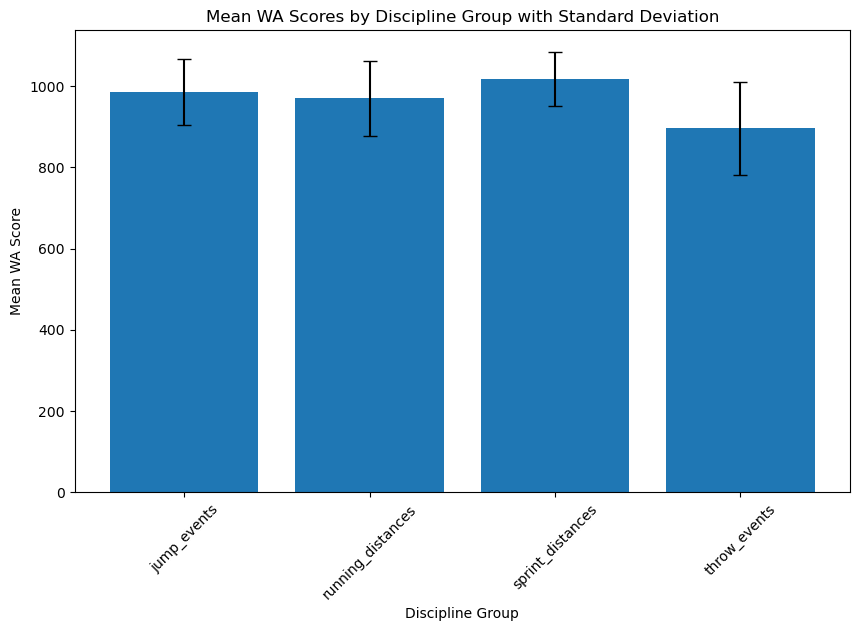

In [84]:
# get mean for all discipline groups
mean_wa_scores = data_wa.groupby('discipline_group')['wa_score'].mean().reset_index()
# get standard deviation for all discipline groups
std_wa_scores = data_wa.groupby('discipline_group')['wa_score'].std().reset_index()

# plot mean wa scores with error bars
plt.figure(figsize=(10, 6))
plt.bar(mean_wa_scores['discipline_group'], mean_wa_scores['wa_score'], yerr=std_wa_scores['wa_score'], capsize=5)
plt.xlabel('Discipline Group')
plt.ylabel('Mean WA Score')
plt.title('Mean WA Scores by Discipline Group with Standard Deviation')
plt.xticks(rotation=45)
plt.show()

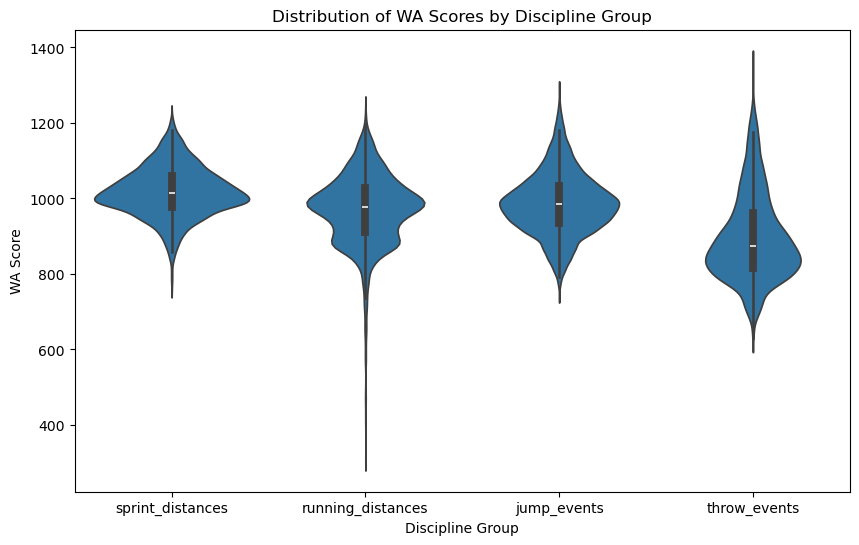

In [85]:
# Plot for every group the distribution of wa_scores using violin plot
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(x='discipline_group', y='wa_score', data=data_wa)
plt.xlabel('Discipline Group')
plt.ylabel('WA Score')
plt.title('Distribution of WA Scores by Discipline Group')
plt.show()

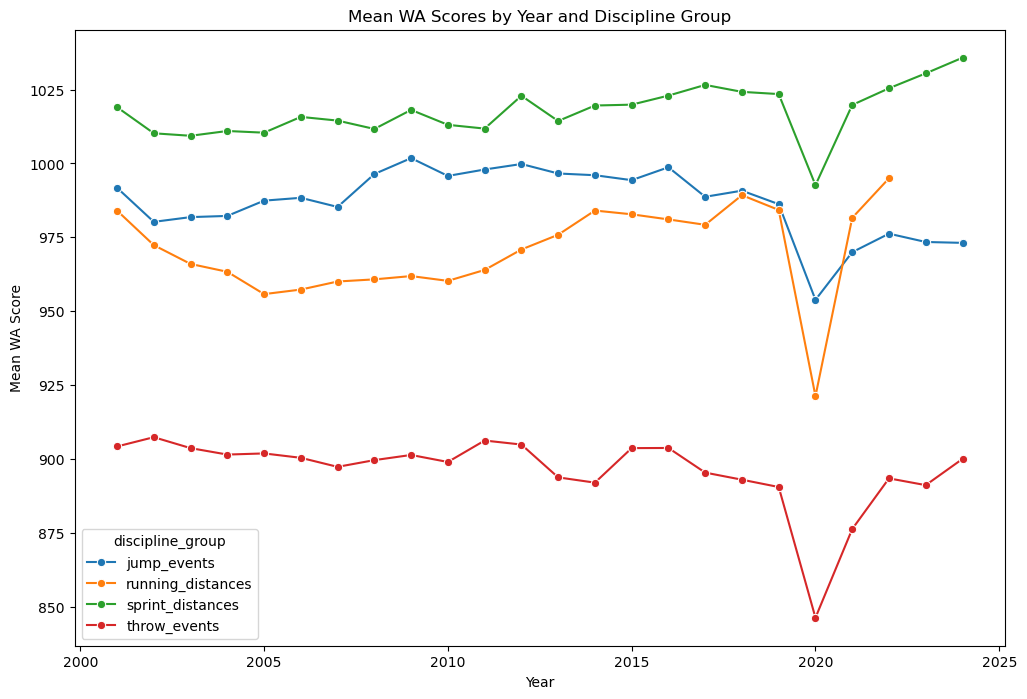

In [ ]:
#Plot the mean for every year and discipline group
mean_wa_scores_year = data_wa.groupby(['jahr', 'discipline_group'])['wa_score'].mean().reset_index()
plt.figure(figsize=(12, 8))
sns.lineplot(x='jahr', y='wa_score', hue='discipline_group', data=mean_wa_scores_year, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean WA Score')
plt.title('Mean WA Scores by Year and Discipline Group - Adults')
plt.show()

The following plot is not valid because of the different weights

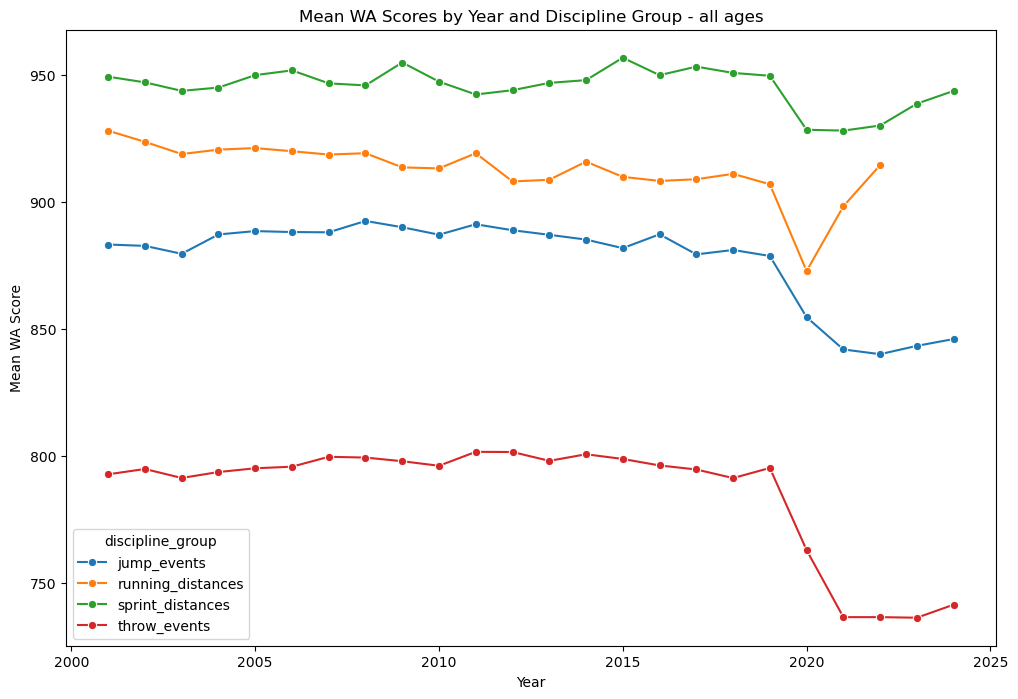

In [99]:
#Plot the mean for every year and discipline group
mean_wa_scores_year = data_wa_all.groupby(['jahr', 'discipline_group'])['wa_score'].mean().reset_index()
plt.figure(figsize=(12, 8))
sns.lineplot(x='jahr', y='wa_score', hue='discipline_group', data=mean_wa_scores_year, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean WA Score')
plt.title('Mean WA Scores by Year and Discipline Group - all ages')
plt.show()

C:\Users\Mattis\AppData\Local\Temp\ipykernel_34372\2597779397.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_athletes = data_wa.groupby(['jahr', 'disziplin']).apply(lambda x: x.nlargest(50, 'wa_score')).reset_index(drop=True)


       jahr geschlecht altersklasse   disziplin leistung  wind  \
0      2001          W       Frauen       100 m    11.17  +0,7   
1      2001          W       Frauen       100 m    11.23  +1,2   
2      2001          W       Frauen       100 m    11.24  +0,6   
3      2001          M      Maenner       100 m    10.21  +1,2   
4      2001          W       Frauen       100 m    11.33  +0,7   
...     ...        ...          ...         ...      ...   ...   
20812  2024          M      Maenner  Weitsprung     7.44  +0,9   
20813  2024          W       Frauen  Weitsprung     6.08  +0,6   
20814  2024          M      Maenner  Weitsprung     7.43  +1,0   
20815  2024          M      Maenner  Weitsprung     7.43   0,0   
20816  2024          W       Frauen  Weitsprung     6.07   0,0   

                    name  geburtsjahr               verein       datum  \
0         Gabi Rockmeier         1973  LG Olympia Dortmund      30.06.   
1        Melanie Paschke         1970      TV Wattenscheid 

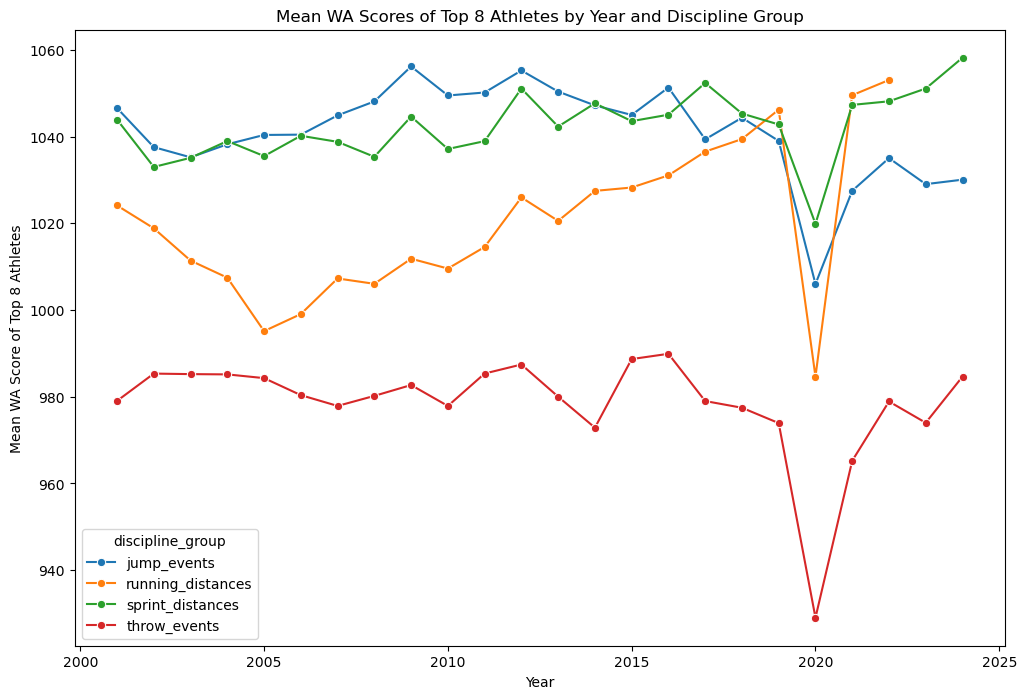

In [97]:
#Plot the mean for every year and discipline group for the top 8 athletes per year per group
top_athletes = data_wa.groupby(['jahr', 'disziplin']).apply(lambda x: x.nlargest(50, 'wa_score')).reset_index(drop=True)
print(top_athletes)
mean_top_wa_scores_year = top_athletes.groupby(['jahr', 'discipline_group'])['wa_score'].mean().reset_index()
plt.figure(figsize=(12, 8))
sns.lineplot(x='jahr', y='wa_score', hue='discipline_group', data=mean_top_wa_scores_year, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean WA Score of Top 8 Athletes')
plt.title('Mean WA Scores of Top 8 Athletes by Year and Discipline Group')
plt.show()

C:\Users\Mattis\AppData\Local\Temp\ipykernel_34372\1232007977.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_jump_athletes = jump_events.groupby(['jahr', 'disziplin', 'altersklasse']).apply(lambda x: x.nlargest(20, 'wa_score')).reset_index(drop=True)


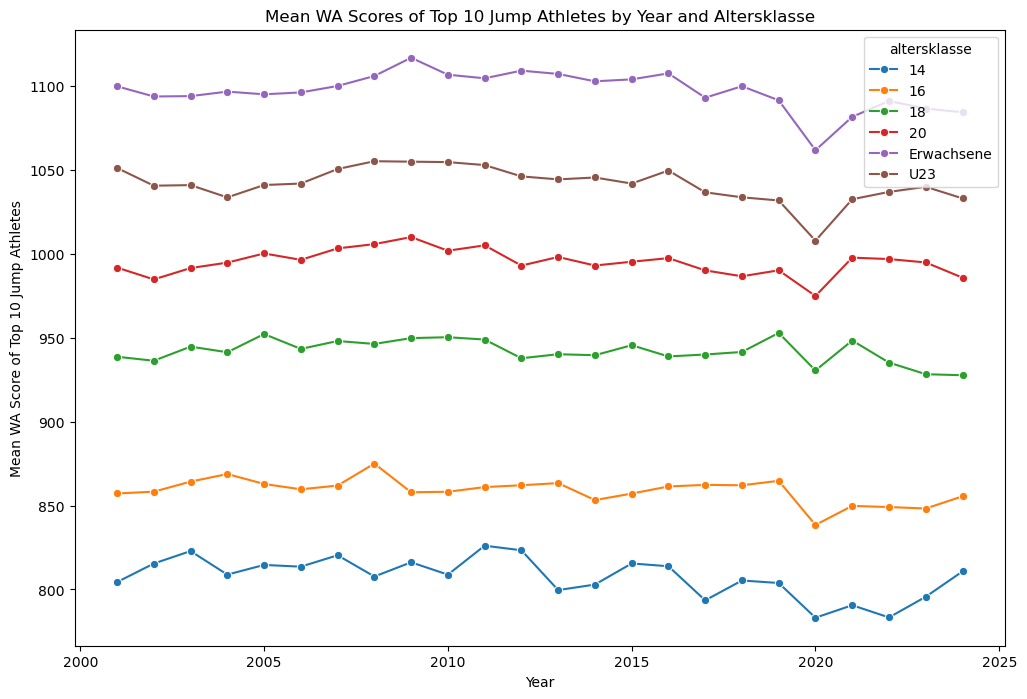

In [98]:
# altersklasse Frauen and Maenner to Erwachsene
data_wa_all['altersklasse'] = data_wa_all['altersklasse'].replace({'Frauen': 'Erwachsene', 'Maenner': 'Erwachsene'})
# Plot from dat_wa_all for the jump events the mean wa_score over the years for altersklasse 18, 20, U23 and Erwachsene
jump_events = data_wa_all[data_wa_all['discipline_group'] == 'jump_events']
#mean for top 10athletes in every discipline per year and altersklasse
top_jump_athletes = jump_events.groupby(['jahr', 'disziplin', 'altersklasse']).apply(lambda x: x.nlargest(20, 'wa_score')).reset_index(drop=True)
mean_top_jump_wa_scores_year = top_jump_athletes.groupby(['jahr', 'altersklasse'])['wa_score'].mean().reset_index()
plt.figure(figsize=(12, 8))
sns.lineplot(x='jahr', y='wa_score', hue='altersklasse', data=mean_top_jump_wa_scores_year, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean WA Score of Top 10 Jump Athletes')
plt.title('Mean WA Scores of Top 10 Jump Athletes by Year and Altersklasse')
plt.show()